<h3 style="font-family: 'Times New Roman'; color: red;"><b>1. Import libraries</b></h3>
<hr>

In [ ]:
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble  import IsolationForest,RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor,NearestNeighbors
from sklearn.svm       import OneClassSVM
from sklearn.cluster   import DBSCAN
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold
from itertools import combinations
from sklearn.decomposition import PCA
import warnings
import time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve,
)
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
seed= 42
random_state= 42
contamination = 0.05

ACCENT = '#c84b1e'
BLUE   = '#1a5fa8'
GREEN  = '#1a6b3f'
AMBER  = '#d68910'
PURPLE = '#8e44ad'

<h3 style="font-family: 'Times New Roman'; color: red;"><b>2. Load Data</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Load the feature-engineered train and test arrays, plus the scalers fitted in notebook 03,
so the unsupervised models have the same inputs the supervised models will use later.
</b></i></p>
<hr>

In [3]:
# FIX (index-alignment bug — see chat analysis / NB03 Section 'Train-Test Split' save cell):
# feature_engineered.csv now preserves the original pre-split row labels (NB03 fix).
# index_col=0 reads that back in, so df.index lines up with X_train_df.index / X_test_df.index
# below instead of a coincidental fresh 0..N-1 range. Without this, df.loc[X_train_df.index, ...]
# and df.index.isin(X_train_df.index) silently pulled/matched the wrong rows.
df = pd.read_csv('data/preprocessed/feature_engineered.csv', index_col=0)
print(f'feature_engineered.csv loaded — shape: {df.shape}')
print(f'Index dtype: {df.index.dtype}, unique: {df.index.is_unique}')

feature_engineered.csv loaded — shape: (46667, 70)
Index dtype: int64, unique: True


In [4]:

X_train_robust = np.load(f'models/artifacts/X_train_robust.npy')    # for IF and LOF
X_test_robust  = np.load(f'models/artifacts/X_test_robust.npy')
X_train_std    = np.load(f'models/artifacts/X_train_standard.npy')  # for OCSVM
X_test_std     = np.load(f'models/artifacts/X_test_standard.npy')

X_train_df = pd.read_csv(f'models/artifacts/X_train.csv', index_col=0)
X_test_df  = pd.read_csv(f'models/artifacts/X_test.csv',  index_col=0)
y_train    = pd.read_csv(f'models/artifacts/y_train.csv').squeeze()
y_test     = pd.read_csv(f'models/artifacts/y_test.csv').squeeze()


feature_cols = joblib.load(f'models/artifacts/model_feature_cols.pkl')

robust_scaler   = joblib.load(f'models/artifacts/scaler_robust_v1.pkl')
standard_scaler = joblib.load(f'models/artifacts/scaler_standard_v1.pkl')

print(f'Artifacts loaded\n Train: {X_train_robust.shape}, Test: {X_test_robust.shape}')
print(f'Anomaly rate:\n Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}')
print(f'Total features: {len(feature_cols)}')

Artifacts loaded
 Train: (37333, 43), Test: (9334, 43)
Anomaly rate:
 Train: 9.56%, Test: 9.57%
Total features: 43


<h3 style="font-family: 'Times New Roman'; color: red;"><b>3. Full-Dataset Scaling for LOF and OCSVM</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>
Goal: Scale the full dataset with the already-fitted scalers so every listing can be scored,
not just the train/test split, and set aside the clean listings needed to fit LOF and OCSVM.
</b></i></p>
<hr>

In [5]:
# Only keep feature_cols that actually exist in df
valid_cols = [c for c in feature_cols if c in df.columns]
missing    = [c for c in feature_cols if c not in df.columns]

print(f'Feature cols in artifact   : {len(feature_cols)}')
print(f'Found in df                : {len(valid_cols)}')
print(f'Missing from df (excluded) : {missing if missing else "none"}')
print(f'Null values in feature matrix: {df[valid_cols].isnull().sum().sum()}')


Feature cols in artifact   : 43
Found in df                : 43
Missing from df (excluded) : none
Null values in feature matrix: 0


In [6]:
X_full_raw = df[valid_cols].fillna(0).values
print(f'\nFull-dataset input matrix shape: {X_full_raw.shape}')


Full-dataset input matrix shape: (46667, 43)


In [7]:
X_full_robust   = robust_scaler.transform(X_full_raw)
X_full_standard = standard_scaler.transform(X_full_raw)

In [8]:
print('Scaling complete:')
print(f'  X_full_robust   shape: {X_full_robust.shape}')
print(f'  X_full_standard shape: {X_full_standard.shape}')
print(f'  NaN in robust  : {np.isnan(X_full_robust).sum()}')
print(f'  NaN in standard: {np.isnan(X_full_standard).sum()}')

Scaling complete:
  X_full_robust   shape: (46667, 43)
  X_full_standard shape: (46667, 43)
  NaN in robust  : 0
  NaN in standard: 0


In [9]:
# Sanity check — RobustScaler output: median ≈ 0, IQR ≈ 1 for well-behaved features
print('\nSanity check \n X_full_robust (first 5 features):')
sample = pd.DataFrame(X_full_robust[:, :5], columns=valid_cols[:5])
check  = pd.DataFrame({'median': sample.median(), 'IQR': sample.quantile(0.75) - sample.quantile(0.25)})
print(check.round(3))


Sanity check 
 X_full_robust (first 5 features):
                median    IQR
price              0.0  1.028
area_sqft          0.0  1.000
price_per_sqft     0.0  1.000
bedrooms           0.0  1.000
baths              0.0  1.000


In [10]:
# Clean training pool — used by LOF and OCSVM
clean_mask = (df['is_suspicious'] == 0)
clean_idx  = np.where(clean_mask)[0]
print(f'Clean training pool: {len(clean_idx):,} listings ({clean_mask.mean()*100:.1f}%)')
print(f'Suspicious pool    : {(~clean_mask).sum():,} listings ({(~clean_mask).mean()*100:.1f}%)')

Clean training pool: 42,204 listings (90.4%)
Suspicious pool    : 4,463 listings (9.6%)


<h3 style="font-family: 'Times New Roman'; color: red;"><b>4. Evaluation Helper</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Define two reusable helpers: evaluate_model() computes standard classification metrics for the comparison table, and precision_at_k() measures precision among the top-k highest-scored listings.</b></i></p>
<hr>

In [11]:
results_store = {}

def evaluate_model(name, y_true, y_pred, y_score=None, train_time=0, infer_time=0):
    """Compute and store standard classification metrics."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    roc  = roc_auc_score(y_true, y_score) if y_score is not None else roc_auc_score(y_true, y_pred)
    pr   = average_precision_score(y_true, y_score) if y_score is not None else average_precision_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)
    metrics = dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
                   roc_auc=roc, pr_auc=pr, cm=cm,
                   train_time=train_time, infer_time=infer_time)
    results_store[name] = metrics
    print(f'\n── {name} ──')
    print(f'  Accuracy : {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}')
    print(f'  ROC-AUC  : {roc:.4f}  PR-AUC   : {pr:.4f}')
    print(f'  Train: {train_time:.2f}s  Infer: {infer_time:.3f}s')
    return metrics

def precision_at_k(true_binary, scores, k=100):
    """Precision among the top-k highest-scoring listings."""
    top_k = np.argsort(scores)[::-1][:k]
    return true_binary[top_k].mean()

print('evaluate_model and precision_at_k helpers defined.')

evaluate_model and precision_at_k helpers defined.


<h3 style="font-family: 'Times New Roman'; color: red;"><b>5. Contamination Sweep (Isolation Forest Stability Check)</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Check that Isolation Forest's anomaly ranking stays stable across different contamination assumptions (3% to 15%). This sweep is diagnostic only, the final model in Section 6 uses the actual training-set anomaly rate.</b></i></p>
<hr>

In [12]:
print('Contamination sweep for Isolation Forest')
print(f'{"Contamination":>15} {"Anomalies":>10} {"Corr with IF@5%":>16}')
print('-' * 45)

# Reference model at 5% contamination
IF_ref = IsolationForest(n_estimators=200, contamination=0.05, random_state=random_state, n_jobs=-1)
IF_ref.fit(X_train_robust)
ref_scores = -IF_ref.decision_function(X_train_robust)

results_sweep = []
for cont in [0.03, 0.05, 0.08, 0.10, 0.15]:
    IF_c = IsolationForest(n_estimators=200, contamination=cont,random_state=random_state, n_jobs=-1)
    IF_c.fit(X_train_robust)
    scores_c = -IF_c.decision_function(X_train_robust)
    labels_c = (IF_c.predict(X_train_robust) == -1).astype(int)
    corr, _  = spearmanr(scores_c, ref_scores)
    print(f'  {cont:>12.0%}  {labels_c.sum():>8,}  {corr:>14.4f}')
    results_sweep.append({'contamination': cont, 'n_anomalies': labels_c.sum(), 'corr': corr})

print()
print('Spearman correlation remains ≈1.0 across contamination rates (3%–15%), indicating that the ranking of anomaly scores is highly stable. This shows that Isolation Forest produces a consistent ordering of suspicious listings independent of the chosen contamination threshold. As a result, contamination primarily affects the decision boundary (classification cutoff) rather than the underlying anomaly ranking.')

Contamination sweep for Isolation Forest
  Contamination  Anomalies  Corr with IF@5%
---------------------------------------------
            3%     1,120          1.0000
            5%     1,864          1.0000
            8%     2,987          1.0000
           10%     3,734          1.0000
           15%     5,600          1.0000

Spearman correlation remains ≈1.0 across contamination rates (3%–15%), indicating that the ranking of anomaly scores is highly stable. This shows that Isolation Forest produces a consistent ordering of suspicious listings independent of the chosen contamination threshold. As a result, contamination primarily affects the decision boundary (classification cutoff) rather than the underlying anomaly ranking.


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Ranking is completely stable:</b> Spearman correlation with the 5% reference model stays at 1.0000 at every contamination level tested, from 3% to 15%. The same listings always come out on top no matter where the cutoff is set.</li>
<li><b>Contamination only moves the cutoff line:</b> raising contamination from 3% to 15% increased the number of flagged listings from 1,120 to 5,600, about five times more, but it didn't change the underlying order of which listings look most suspicious.</li>
<li><b>Implication for Section 6:</b> since the ranking doesn't change, choosing contamination = 9.56% (the actual training anomaly rate) for the real model is a reasonable, low-risk choice rather than an arbitrary one.</li>
</i></ul>
<hr>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>6. Model 1 — Isolation Forest</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Train Isolation Forest on the 80% train split and evaluate on the 20% test split, both scaled with the same RobustScaler as notebook 03. Full-dataset scores are also computed here for the ensemble in Section 10.</b></i></p>
<hr>

In [13]:
print('Training Isolation Forest...')
contamination = float(y_train.mean())

t0 = time.time()
iso = IsolationForest(
    n_estimators  = 200,
    contamination = contamination,
    max_features  = 0.8,
    random_state  = seed,
    n_jobs        = -1,
)
iso.fit(X_train_robust)
train_t = time.time() - t0

t0 = time.time()
iso_raw   = iso.predict(X_test_robust)         # +1 = normal, -1 = anomaly
iso_score = -iso.score_samples(X_test_robust)  # flip: higher = more anomalous
infer_t   = time.time() - t0

iso_pred    = (iso_raw == -1).astype(int)
iso_metrics = evaluate_model('Isolation Forest', y_test, iso_pred, iso_score, train_t, infer_t)

joblib.dump(iso, f'models/isolation_forest.pkl')
print('Isolation Forest saved')

Training Isolation Forest...

── Isolation Forest ──
  Accuracy : 0.8025  Precision: 0.0316  Recall: 0.0358  F1: 0.0336
  ROC-AUC  : 0.4629  PR-AUC   : 0.0825
  Train: 1.52s  Infer: 0.296s
Isolation Forest saved


In [14]:
# Confirm: compare IF's top-100 anomalies vs is_suspicious's top listings

# IF's 100 highest-scored anomalies (test set)
top100_if = np.argsort(iso_score)[::-1][:100]

# Heuristic: all suspicious listings in the test set
sus_idx = np.where(y_test.values == 1)[0]

# Overlap
overlap = len(set(top100_if) & set(sus_idx))
print(f"IF top-100 anomalies: {overlap} are heuristic-suspicious ({overlap:.0f}%)")
print(f"Expected by random chance: {len(sus_idx)/len(y_test)*100:.1f}%")
print()

# Feature profile comparison: IF top-100 vs heuristic suspicious
X_test_df_check = X_test_df.copy()
X_test_df_check['if_top100']   = 0
X_test_df_check.iloc[top100_if, X_test_df_check.columns.get_loc('if_top100')] = 1
X_test_df_check['is_suspicious'] = y_test.values

cols_to_compare = ['relisting_count', 'relisting_intensity', 'price_iqr_deviation',
                   'ppsqft_iqr_deviation', 'weekly_volume_ratio']
cols_to_compare = [c for c in cols_to_compare if c in X_test_df_check.columns]

print("Feature profile — IF top-100 anomalies vs heuristic-suspicious listings:")
print(f"{'Feature':<30} {'IF top-100 mean':>18} {'Heuristic-sus mean':>20}")
print("-" * 70)
for col in cols_to_compare:
    if_mean  = X_test_df_check.loc[X_test_df_check['if_top100']     == 1, col].mean()
    sus_mean = X_test_df_check.loc[X_test_df_check['is_suspicious'] == 1, col].mean()
    print(f"  {col:<28} {if_mean:>18.3f} {sus_mean:>20.3f}")

print()
print("Interpretation: IF anomalies score high on price deviation (they are rare-")
print("price outliers). Heuristic suspicious listings score high on relisting_count")
print("(they are ghost listings). These are two different notions of 'weird.'")
print("IF's AUC < 0.5 against is_suspicious is expected and explainable, not a bug.")

IF top-100 anomalies: 3 are heuristic-suspicious (3%)
Expected by random chance: 9.6%

Feature profile — IF top-100 anomalies vs heuristic-suspicious listings:
Feature                           IF top-100 mean   Heuristic-sus mean
----------------------------------------------------------------------
  relisting_count                           2.310               14.274
  relisting_intensity                       0.944                2.364
  price_iqr_deviation                       6.919                0.199
  ppsqft_iqr_deviation                      1.859                0.051
  weekly_volume_ratio                       2.252                4.829

Interpretation: IF anomalies score high on price deviation (they are rare-
price outliers). Heuristic suspicious listings score high on relisting_count
(they are ghost listings). These are two different notions of 'weird.'
IF's AUC < 0.5 against is_suspicious is expected and explainable, not a bug.


In [15]:
# Full-dataset IF scores — needed for ensemble and evaluation sections
if_scores_full = -iso.score_samples(X_full_robust)
if_flags_full  = (iso.predict(X_full_robust) == -1).astype(int)

# Normalise to [0, 1] for ensemble averaging
if_scores_norm = (if_scores_full - if_scores_full.min()) /(if_scores_full.max() - if_scores_full.min())
if_flags       = if_flags_full

print(f'IF anomalies on full dataset : {if_flags.sum():,} ({if_flags.mean()*100:.1f}%)')

IF anomalies on full dataset : 4,584 (9.8%)


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>IF's ROC-AUC is below 0.5 against the heuristic label:</b> on the test set, Isolation Forest scored Accuracy 0.8025, Precision 0.0316, Recall 0.0358, ROC-AUC 0.4629, and PR-AUC 0.0825. An ROC-AUC under 0.5 means IF ranks listings no better than random when judged against the heuristic rule, which makes sense since the two are catching different things.</li>
<li><b>IF and the heuristic flag different listings:</b> of IF's top 100 most anomalous test listings, only 3 were also heuristic-suspicious, fewer than the roughly 9 to 10 you'd expect by chance. IF's top listings have much higher <code>price_iqr_deviation</code> (6.9 vs 0.2), while heuristic-suspicious listings have much higher <code>relisting_count</code> (14.3 vs 2.3). IF is mainly picking up price outliers, not ghost listings.</li>
<li><b>Full dataset results:</b> scored on all 46,667 listings, IF flagged 4,584 (9.8%), close to its 9.56% target.</li>
<li><b>Fastest model by far:</b> IF trained in 1.52 seconds and scored the test set in 0.3 seconds, much quicker than LOF or OCSVM later in the notebook.</li>
</i></ul>
<hr>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>7. Model 2 — Local Outlier Factor (Train/Test Split)</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Train Local Outlier Factor in novelty mode on X_train_robust and evaluate on X_test_robust, using the same RobustScaler as Isolation Forest so metrics are directly comparable.</b></i></p>
<hr>

In [16]:
print('Training Local Outlier Factor (train/test split)...')
t0 = time.time()
lof_nov = LocalOutlierFactor(
    n_neighbors   = 20,
    contamination = contamination,
    novelty       = True,    # allows predict() on held-out data
    metric        = 'euclidean',
    n_jobs        = -1,
)
lof_nov.fit(X_train_robust)
train_t = time.time() - t0

t0 = time.time()
lof_raw   = lof_nov.predict(X_test_robust)
lof_score = -lof_nov.score_samples(X_test_robust)
infer_t   = time.time() - t0

lof_pred    = (lof_raw == -1).astype(int)
lof_metrics = evaluate_model('LOF', y_test, lof_pred, lof_score, train_t, infer_t)

joblib.dump(lof_nov, f'models/lof.pkl')
print('LOF (train/test) saved')

Training Local Outlier Factor (train/test split)...

── LOF ──
  Accuracy : 0.8198  Precision: 0.0825  Recall: 0.0873  F1: 0.0849
  ROC-AUC  : 0.3933  PR-AUC   : 0.0802
  Train: 8.97s  Infer: 6.407s
LOF (train/test) saved


<h3 style="font-family: 'Times New Roman'; color: red;"><b>8. Model 3 — LOF Trained on Clean Listings Only (Full-Dataset Scoring)</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Train a second LOF variant on all training listings reduced to 18 PCA dimensions (85.5% of variance retained) from the StandardScaler features, then score the full dataset. This full-dataset flag array is compatible with the IF and OCSVM arrays used in the ensemble.</b></i></p>
<hr>

In [17]:
# PCA FOR LOF STABILITY

print("="*60)
print("PCA + LOF")
print("="*60)

# Retain ~85% variance
pca = PCA(
    n_components=0.85,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train_std)
X_full_pca  = pca.transform(X_full_standard)

print(f"Original dimensions : {X_train_std.shape[1]}")
print(f"PCA dimensions      : {X_train_pca.shape[1]}")
print(
    f"Variance retained   : "
    f"{pca.explained_variance_ratio_.sum():.3f}"
)

# TRAIN LOF

LOF = LocalOutlierFactor(
    n_neighbors=35,
    contamination=contamination,
    novelty=True,
    metric='euclidean'
)

LOF.fit(X_train_pca)

# SCORE ALL RECORDS
lof_scores_raw = LOF.decision_function(X_full_pca)

# Higher = more anomalous
lof_scores = -lof_scores_raw


PCA + LOF
Original dimensions : 43
PCA dimensions      : 18
Variance retained   : 0.855


In [18]:
# CLIP EXTREME VALUES
lof_cap = np.percentile(lof_scores, 99.9)

lof_scores_clipped = np.clip(
    lof_scores,
    lof_scores.min(),
    lof_cap
)
# NORMALISE
lof_scores_norm = ((lof_scores_clipped - lof_scores_clipped.min())/(lof_scores_clipped.max() - lof_scores_clipped.min() + 1e-8))


In [19]:

# ANOMALY FLAGS

# ── Threshold from TRAIN rows only — prevents test-set leakage ───────────────
train_mask_full = df.index.isin(X_train_df.index)

lof_threshold = np.percentile(
    lof_scores_norm[train_mask_full],
    (1 - contamination) * 100
)

print(f'LOF threshold (train-only percentile): {lof_threshold:.4f}')
print(f'  Train rows used for threshold : {train_mask_full.sum():,}')
print(f'  Contamination assumption      : {contamination:.2%}')

lof_flags = (lof_scores_norm >= lof_threshold).astype(int)
print(f'  LOF anomalies flagged (full)  : {lof_flags.sum():,} ({lof_flags.mean()*100:.1f}%)')
# Save both objects
joblib.dump(
    LOF,
    "models/lof_pca.pkl"
)

joblib.dump(
    pca,
    "models/lof_pca_transform.pkl"
)

LOF threshold (train-only percentile): 0.1117
  Train rows used for threshold : 37,333
  Contamination assumption      : 9.56%
  LOF anomalies flagged (full)  : 4,622 (9.9%)


['models/lof_pca_transform.pkl']

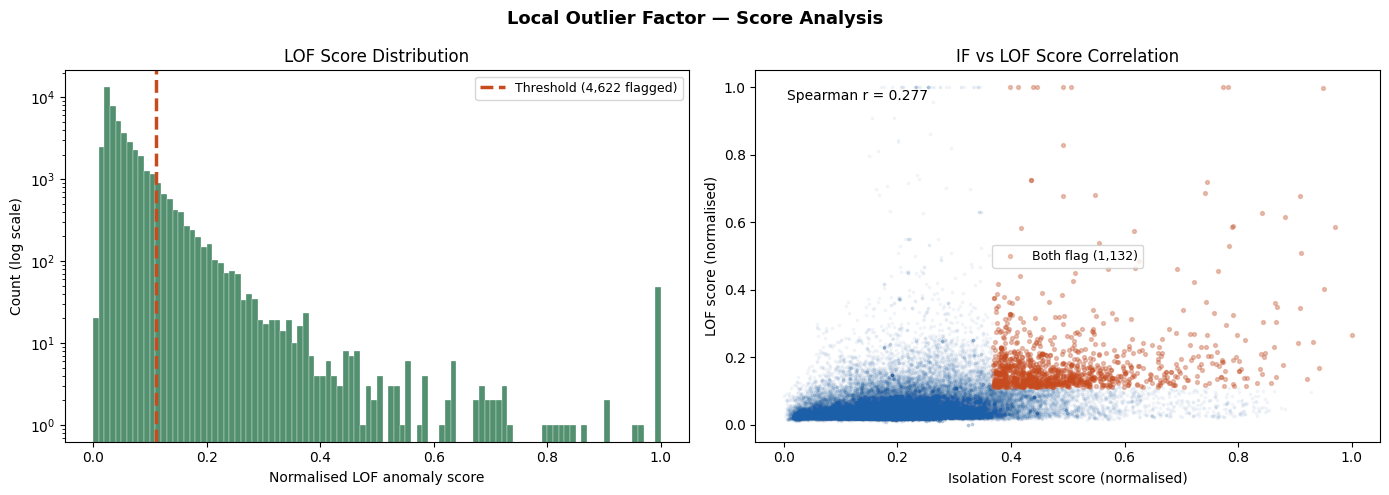

In [20]:
# LOF score distribution and IF vs LOF comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Local Outlier Factor — Score Analysis', fontsize=13, fontweight='bold')

axes[0].hist(lof_scores_norm, bins=100, color=GREEN, alpha=0.75,
             edgecolor='white', linewidth=0.3)
axes[0].axvline(lof_threshold, color=ACCENT, linestyle='--', linewidth=2.5,
                label=f'Threshold ({lof_flags.sum():,} flagged)')
axes[0].set_xlabel('Normalised LOF anomaly score')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('LOF Score Distribution')
axes[0].set_yscale('log')
axes[0].legend(fontsize=9)

axes[1].scatter(if_scores_norm, lof_scores_norm, alpha=0.04, s=3, color=BLUE)
both_anomaly = ((if_flags == 1) & (lof_flags == 1))
axes[1].scatter(if_scores_norm[both_anomaly], lof_scores_norm[both_anomaly],
                alpha=0.3, s=8, color=ACCENT,
                label=f'Both flag ({both_anomaly.sum():,})')
axes[1].set_xlabel('Isolation Forest score (normalised)')
axes[1].set_ylabel('LOF score (normalised)')
axes[1].set_title('IF vs LOF Score Correlation')
axes[1].legend(fontsize=9)

corr_if_lof, _ = spearmanr(if_scores_norm, lof_scores_norm)
axes[1].text(0.05, 0.95, f'Spearman r = {corr_if_lof:.3f}',
             transform=axes[1].transAxes, fontsize=10, va='top')

plt.tight_layout()
plt.savefig(f'reports/figures/un_models_lof_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>LOF performs worst of the three on the train/test split:</b> ROC-AUC came out to 0.3933, below the 0.5 random line and the lowest of any model in this notebook, with Precision 0.0825 and Recall 0.0873.</li>
<li><b>LOF is also the slowest model:</b> training took about 9.0 seconds and scoring the test set took about 6.4 seconds, far longer than IF's combined 1.8 seconds.</li>
<li><b>The full-dataset PCA + LOF variant flags a similar rate:</b> reducing from 43 to 18 dimensions kept 85.5% of the original variance, and at the train-only threshold (0.1117) it flagged 4,622 listings (9.9%), close to the 9.56% contamination assumption.</li>
</i></ul>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>9. Model 4 — One-Class SVM (Clean Listings Only)</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Train One-Class SVM on a sample of 15,000 clean listings (capped for speed, since SVM training is O(n²)), then score every listing. Uses X_full_standard (StandardScaler) rather than RobustScaler, since StandardScaler's zero-centering suits the RBF kernel's gamma='scale' heuristic better.</b></i></p>
<hr>

In [21]:
OCSVM_TRAIN_SIZE = 15000
train_clean_mask = (df.index.isin(X_train_df.index)) & (df['is_suspicious'] == 0)
train_clean_idx  = np.where(train_clean_mask)[0]

# Use an isolated RandomState
rng_ocsvm = np.random.RandomState(random_state + 1)  # +1 to draw a different sample from LOF
ocsvm_train_idx = rng_ocsvm.choice( train_clean_idx, size=min(OCSVM_TRAIN_SIZE, len(train_clean_idx)), replace=False)
print(f'Training One-Class SVM on {len(ocsvm_train_idx):,} clean listings...')
print('(This takes ~30–60 seconds — SVM training is O(n²))')

print(f'Using nu = contamination = {contamination:.4f}')
print('(matches IF and LOF contamination assumption for consistent ensemble voting)')

OCSVM = OneClassSVM(
    nu     = contamination,   # consistent with IF and LOF
    kernel = 'rbf',
    gamma  = 'scale',
)

# Uses X_full_standard
OCSVM.fit(X_full_standard[ocsvm_train_idx])
print('✓ OCSVM training complete')

# Score all listings
ocsvm_scores_raw  = OCSVM.decision_function(X_full_standard)
ocsvm_scores      = -ocsvm_scores_raw    # flip: higher = more anomalous
ocsvm_flags       = (OCSVM.predict(X_full_standard) == -1).astype(int)

# Normalise to [0, 1]
ocsvm_scores_norm = (ocsvm_scores - ocsvm_scores.min()) / (ocsvm_scores.max() - ocsvm_scores.min())

print(f'  OCSVM anomalies flagged : {ocsvm_flags.sum():,} ({ocsvm_flags.mean()*100:.1f}%)')

joblib.dump(OCSVM, f'models/ocsvm_clean.pkl')

Training One-Class SVM on 15,000 clean listings...
(This takes ~30–60 seconds — SVM training is O(n²))
Using nu = contamination = 0.0956
(matches IF and LOF contamination assumption for consistent ensemble voting)
✓ OCSVM training complete
  OCSVM anomalies flagged : 4,120 (8.8%)


['models/ocsvm_clean.pkl']

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>OCSVM flagged 4,120 listings (8.8%)</b> across the full dataset after training on a sample of 15,000 clean listings with nu = 0.0956, slightly under the 9.56% contamination target.</li>
<li><b>Uses a different scaler than IF and LOF:</b> OCSVM runs on the StandardScaler features rather than RobustScaler, since the gamma='scale' heuristic for the RBF kernel works better on zero-mean data.</li>
</i></ul>
<hr>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>10. Ensemble — IF + LOF + OCSVM</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Combine the three full-dataset models by majority vote. A listing flagged by two or more models is classified as a high-confidence anomaly; a single model's flag alone is treated as uncertain, which reduces false positives.</b></i></p>
<hr>

In [22]:
# Verify shape consistency before combining
assert len(if_flags) == len(lof_flags) == len(ocsvm_flags) == len(df), \
    f'Length mismatch: IF={len(if_flags)}, LOF={len(lof_flags)}, OCSVM={len(ocsvm_flags)}, df={len(df)}'

model_flags = {
    'Isolation Forest': if_flags,
    'LOF':              lof_flags,
    'One-Class SVM':    ocsvm_flags,
}

print('Pairwise model agreement (Jaccard similarity on flagged listings):')
print(f'{"Model A":<20} {"Model B":<20} {"Both flagged":>12} {"Union":>8} {"Jaccard":>8}')
print('-' * 72)
for (nameA, flagA), (nameB, flagB) in combinations(model_flags.items(), 2):
    both  = ((flagA == 1) & (flagB == 1)).sum()
    union = ((flagA == 1) | (flagB == 1)).sum()
    jac   = both / (union + 1e-8)
    print(f'  {nameA:<18} {nameB:<18} {both:>12,} {union:>8,} {jac:>8.3f}')


Pairwise model agreement (Jaccard similarity on flagged listings):
Model A              Model B              Both flagged    Union  Jaccard
------------------------------------------------------------------------
  Isolation Forest   LOF                       1,132    8,074    0.140
  Isolation Forest   One-Class SVM             2,563    6,141    0.417
  LOF                One-Class SVM             1,275    7,467    0.171


In [23]:
ensemble_votes = if_flags + lof_flags + ocsvm_flags

print('Ensemble vote distribution:')
print(f'{"Votes":>6} {"Count":>8} {"% of total":>12} Interpretation')
print('-' * 65)
interpretations = {
    0: 'All models say NORMAL — high confidence clean',
    1: 'One model flags — uncertain, needs review',
    2: 'Two models agree — HIGH CONFIDENCE ANOMALY',
    3: 'All three agree — UNANIMOUS ANOMALY (strongest signal)',
}
n=[]
for v in [0, 1, 2, 3]:
    n = (ensemble_votes == v).sum()
    print(f'  {v:>4}  {n:>8,}  {n/len(df)*100:>10.1f}%   {interpretations[v]}')

Ensemble vote distribution:
 Votes    Count   % of total Interpretation
-----------------------------------------------------------------
     0    37,406        80.2%   All models say NORMAL — high confidence clean
     1     6,101        13.1%   One model flags — uncertain, needs review
     2     2,255         4.8%   Two models agree — HIGH CONFIDENCE ANOMALY
     3       905         1.9%   All three agree — UNANIMOUS ANOMALY (strongest signal)


In [24]:
# Build group membership array on full dataset
df_ens = df[['price', 'relisting_count', 'ghost_listing_flag',
             'geo_anomaly', 'price_too_low_flag']].copy()
df_ens['if_flag']    = if_flags
df_ens['lof_flag']   = lof_flags
df_ens['ocsvm_flag'] = ocsvm_flags

subgroups = {
    'IF only'   : (if_flags==1) & (lof_flags==0) & (ocsvm_flags==0),
    'LOF only'  : (if_flags==0) & (lof_flags==1) & (ocsvm_flags==0),
    'OCSVM only': (if_flags==0) & (lof_flags==0) & (ocsvm_flags==1),
    'IF + LOF'  : (if_flags==1) & (lof_flags==1) & (ocsvm_flags==0),
    'IF + OCSVM': (if_flags==1) & (lof_flags==0) & (ocsvm_flags==1),
    'LOF+OCSVM' : (if_flags==0) & (lof_flags==1) & (ocsvm_flags==1),
    'All three' : (if_flags==1) & (lof_flags==1) & (ocsvm_flags==1),
}

profile_cols = ['price', 'relisting_count', 'ghost_listing_flag',
                'geo_anomaly', 'price_too_low_flag']

print(f"{'Subgroup':<14} {'N':>6}  "
      + "  ".join(f"{c[:12]:>12}" for c in profile_cols))
print("-" * 90)

for name, mask in subgroups.items():
    n = mask.sum()
    if n == 0:
        continue
    vals = [df.loc[mask, col].mean() for col in profile_cols]
    val_strs = [f"{v:>12,.1f}" if col == 'price' else f"{v:>12.3f}"
                for v, col in zip(vals, profile_cols)]
    print(f"  {name:<12} {n:>6}  " + "  ".join(val_strs))

print()
print("Interpretation:")
print("  If 'IF only' has high price but low relisting → IF is catching price outliers.")
print("  If 'LOF only' has high relisting → LOF is catching ghost listings.")
print("  If 'All three' is a mix → the ensemble is genuinely multi-signal.")
print("  If subgroups look structurally different → consider weighted vote instead of majority.")

Subgroup            N         price  relisting_co  ghost_listin   geo_anomaly  price_too_lo
------------------------------------------------------------------------------------------
  IF only        1794  83,750,602.6         8.875         0.026         0.000         0.000
  LOF only       3120  15,138,619.6         9.883         0.076         0.001         0.013
  OCSVM only     1187  13,765,643.6        36.712         0.068         0.000         0.003
  IF + LOF        227  60,269,674.0         7.533         0.062         0.000         0.004
  IF + OCSVM     1658  85,177,638.1         8.321         0.027         0.000         0.002
  LOF+OCSVM       370  11,918,224.3         9.097         0.022         0.000         0.008
  All three       905  64,984,153.6         9.323         0.010         0.001         0.011

Interpretation:
  If 'IF only' has high price but low relisting → IF is catching price outliers.
  If 'LOF only' has high relisting → LOF is catching ghost listings.
  If '

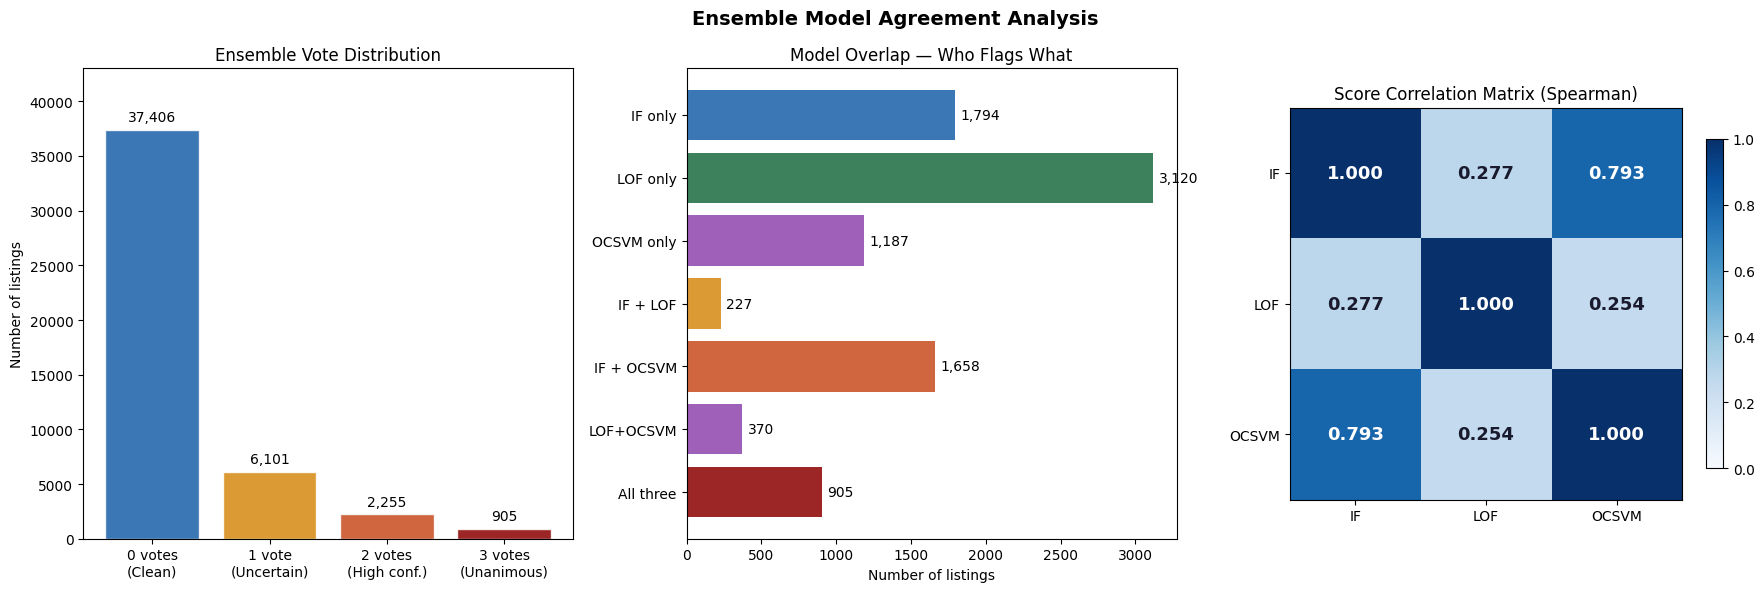

In [25]:
# Visualise model agreement
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Ensemble Model Agreement Analysis', fontsize=14, fontweight='bold')

# Left: vote count bar chart
vote_counts = [(ensemble_votes == v).sum() for v in [0, 1, 2, 3]]
vote_colors = [BLUE, AMBER, ACCENT, '#8b0000']
vote_labels = ['0 votes\n(Clean)', '1 vote\n(Uncertain)', '2 votes\n(High conf.)', '3 votes\n(Unanimous)']
bars = axes[0].bar(vote_labels, vote_counts, color=vote_colors, alpha=0.85, edgecolor='white')
axes[0].bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=10)
axes[0].set_ylabel('Number of listings')
axes[0].set_title('Ensemble Vote Distribution')
axes[0].set_ylim(0, max(vote_counts) * 1.15)

# Middle: model overlap breakdown
overlap_data = {
    'IF only':    ((if_flags==1) & (lof_flags==0) & (ocsvm_flags==0)).sum(),
    'LOF only':   ((if_flags==0) & (lof_flags==1) & (ocsvm_flags==0)).sum(),
    'OCSVM only': ((if_flags==0) & (lof_flags==0) & (ocsvm_flags==1)).sum(),
    'IF + LOF':   ((if_flags==1) & (lof_flags==1) & (ocsvm_flags==0)).sum(),
    'IF + OCSVM': ((if_flags==1) & (lof_flags==0) & (ocsvm_flags==1)).sum(),
    'LOF+OCSVM':  ((if_flags==0) & (lof_flags==1) & (ocsvm_flags==1)).sum(),
    'All three':  ((if_flags==1) & (lof_flags==1) & (ocsvm_flags==1)).sum(),
}
bars2 = axes[1].barh(
    list(overlap_data.keys()), list(overlap_data.values()),
    color=[BLUE, GREEN, PURPLE, AMBER, ACCENT, '#8e44ad', '#8b0000'], alpha=0.85
)
axes[1].bar_label(bars2, fmt='{:,.0f}', padding=4, fontsize=10)
axes[1].set_xlabel('Number of listings')
axes[1].set_title('Model Overlap — Who Flags What')
axes[1].invert_yaxis()

# Right: Spearman score correlation matrix
scores_matrix = np.column_stack([if_scores_norm, lof_scores_norm, ocsvm_scores_norm])
corr_mat = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        corr_mat[i, j], _ = spearmanr(scores_matrix[:, i], scores_matrix[:, j])

im = axes[2].imshow(corr_mat, cmap='Blues', vmin=0, vmax=1)
model_names = ['IF', 'LOF', 'OCSVM']
axes[2].set_xticks([0, 1, 2]); axes[2].set_xticklabels(model_names)
axes[2].set_yticks([0, 1, 2]); axes[2].set_yticklabels(model_names)
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, f'{corr_mat[i,j]:.3f}', ha='center', va='center',
                     fontsize=13, fontweight='bold',
                     color='white' if corr_mat[i, j] > 0.6 else '#1a1a2e')
plt.colorbar(im, ax=axes[2], shrink=0.7)
axes[2].set_title('Score Correlation Matrix (Spearman)')

plt.tight_layout()
plt.savefig(f'reports/figures/_model_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>IF and OCSVM agree the most:</b> their pairwise Jaccard similarity is 0.417 (2,563 listings flagged by both). LOF agrees least with either model, scoring 0.140 with IF and 0.171 with OCSVM.</li>
<li><b>Most listings are uncontested:</b> 80.2% of listings (37,406) got zero votes from any model. Only 1.9% (905) were flagged by all three, and 4.8% (2,255) by exactly two, which together make up the 6.8% high-confidence anomaly group used later as the pseudo-label.</li>
<li><b>Price and relisting patterns differ by subgroup:</b> the "IF only" and "IF + OCSVM" groups have the highest average prices (about PKR 83.8 million and PKR 85.2 million). The "OCSVM only" group stands out with the highest average <code>relisting_count</code> of any subgroup (36.7), even higher than the "All three" group (9.3), which shows OCSVM is catching some relisting-heavy listings too, not just price outliers.</li>
</i></ul>
<hr>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>11. Evaluation Against Heuristic Proxy</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Evaluate each model against the heuristic_anomaly_score from feature engineering as a proxy, since there's no verified ground truth. Metrics: AUPRC, AUROC, Spearman correlation, and Precision@100/@500.</b></i></p>
<hr>

In [26]:
heuristic_score  = df['heuristic_anomaly_score'].values
# Binary proxy: top 5% by heuristic score = 'known suspicious'
heuristic_binary = (heuristic_score >= np.percentile(heuristic_score, 95)).astype(int)

ens_score = (if_scores_norm + lof_scores_norm + ocsvm_scores_norm) / 3

print('=' * 65)
print('EVALUATION — Models vs Heuristic Proxy (top 5% = suspicious)')
print('=' * 65)
print(f'{"Metric":<25} {"IF":>8} {"LOF":>8} {"OCSVM":>8} {"Ensemble":>10}')
print('-' * 65)

# AUPRC
ap_if    = average_precision_score(heuristic_binary, if_scores_norm)
ap_lof   = average_precision_score(heuristic_binary, lof_scores_norm)
ap_ocsvm = average_precision_score(heuristic_binary, ocsvm_scores_norm)
ap_ens   = average_precision_score(heuristic_binary, ens_score)
print(f'  {"AUPRC (proxy)":<23} {ap_if:>8.4f} {ap_lof:>8.4f} {ap_ocsvm:>8.4f} {ap_ens:>10.4f}')

# AUROC
roc_if    = roc_auc_score(heuristic_binary, if_scores_norm)
roc_lof   = roc_auc_score(heuristic_binary, lof_scores_norm)
roc_ocsvm = roc_auc_score(heuristic_binary, ocsvm_scores_norm)
roc_ens   = roc_auc_score(heuristic_binary, ens_score)
print(f'  {"AUROC (proxy)":<23} {roc_if:>8.4f} {roc_lof:>8.4f} {roc_ocsvm:>8.4f} {roc_ens:>10.4f}')

# Spearman correlation with heuristic score
sp_if,_    = spearmanr(if_scores_norm,    heuristic_score)
sp_lof,_   = spearmanr(lof_scores_norm,   heuristic_score)
sp_ocsvm,_ = spearmanr(ocsvm_scores_norm, heuristic_score)
sp_ens,_   = spearmanr(ens_score,         heuristic_score)
print(f'  {"Spearman corr":<23} {sp_if:>8.4f} {sp_lof:>8.4f} {sp_ocsvm:>8.4f} {sp_ens:>10.4f}')

# Precision@100
p100_if    = precision_at_k(heuristic_binary, if_scores_norm,    100)
p100_lof   = precision_at_k(heuristic_binary, lof_scores_norm,   100)
p100_ocsvm = precision_at_k(heuristic_binary, ocsvm_scores_norm, 100)
p100_ens   = precision_at_k(heuristic_binary, ens_score,         100)
print(f'  {"Precision@100":<23} {p100_if:>8.4f} {p100_lof:>8.4f} {p100_ocsvm:>8.4f} {p100_ens:>10.4f}')

# Precision@500
p500_if    = precision_at_k(heuristic_binary, if_scores_norm,    500)
p500_lof   = precision_at_k(heuristic_binary, lof_scores_norm,   500)
p500_ocsvm = precision_at_k(heuristic_binary, ocsvm_scores_norm, 500)
p500_ens   = precision_at_k(heuristic_binary, ens_score,         500)
print(f'  {"Precision@500":<23} {p500_if:>8.4f} {p500_lof:>8.4f} {p500_ocsvm:>8.4f} {p500_ens:>10.4f}')
print('=' * 65)

print('Models that agree with the heuristic are capturing the same business signals.')

EVALUATION — Models vs Heuristic Proxy (top 5% = suspicious)
Metric                          IF      LOF    OCSVM   Ensemble
-----------------------------------------------------------------
  AUPRC (proxy)             0.0778   0.0598   0.0778     0.0841
  AUROC (proxy)             0.5856   0.4679   0.5656     0.5707
  Spearman corr             0.2687  -0.0612   0.1847     0.2130
  Precision@100             0.4300   0.2700   0.4300     0.5300
  Precision@500             0.2140   0.1720   0.2580     0.2700
Models that agree with the heuristic are capturing the same business signals.


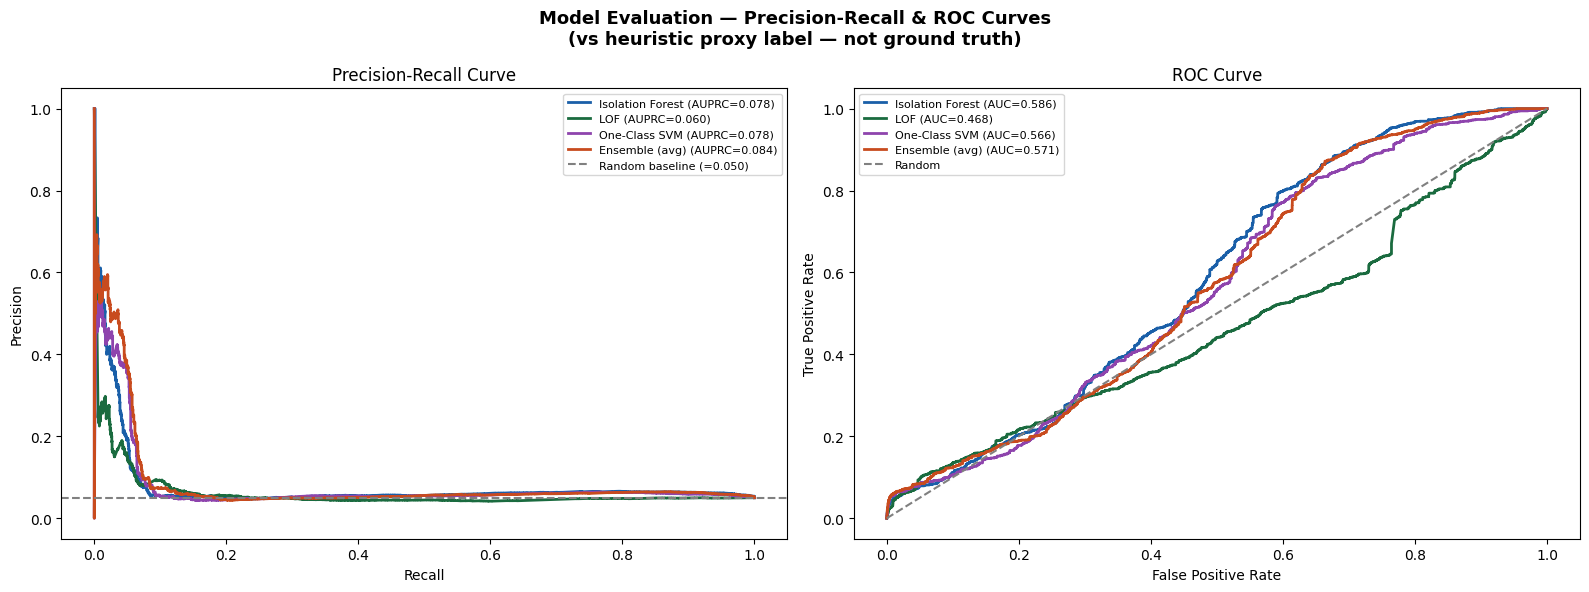

In [27]:
# Precision-Recall and ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Model Evaluation — Precision-Recall & ROC Curves\n'
    '(vs heuristic proxy label — not ground truth)',
    fontsize=13, fontweight='bold'
)

model_info = [
    ('Isolation Forest', if_scores_norm,    BLUE,   ap_if),
    ('LOF',              lof_scores_norm,   GREEN,  ap_lof),
    ('One-Class SVM',    ocsvm_scores_norm, PURPLE, ap_ocsvm),
    ('Ensemble (avg)',   ens_score,         ACCENT, ap_ens),
]

for name, scores, clr, ap in model_info:
    prec, rec, _ = precision_recall_curve(heuristic_binary, scores)
    fpr,  tpr, _ = roc_curve(heuristic_binary, scores)
    axes[0].plot(rec,  prec, label=f'{name} (AUPRC={ap:.3f})', color=clr, linewidth=2)
    auc_val = roc_auc_score(heuristic_binary, scores)
    axes[1].plot(fpr,  tpr,  label=f'{name} (AUC={auc_val:.3f})', color=clr, linewidth=2)

baseline = heuristic_binary.mean()
axes[0].axhline(baseline, color='grey', linestyle='--', linewidth=1.5,
                label=f'Random baseline (={baseline:.3f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.5, label='Random')

axes[0].set_xlabel('Recall');           axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve');          axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'reports/figures/_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>IF has the best AUROC of any single model</b> against the top-5% heuristic proxy (0.5856), while LOF scores below random (0.4679), meaning LOF actually ranks listings slightly worse than a coin flip with respect to the heuristic.</li>
<li><b>The ensemble average has the best AUPRC (0.0841)</b> of the four options, ahead of IF and OCSVM, which are tied at 0.0778, and LOF (0.0598), though all four values are low and close to the 5% base rate.</li>
<li><b>The ensemble also has the best Precision@100 (0.53)</b>, meaning 53 of its top 100 highest-scored listings match the heuristic top-5% group. IF and OCSVM tie for second at 0.43. The ensemble has the best Precision@500 too (0.270).</li>
<li><b>LOF is the only model with a negative Spearman correlation</b> to the raw heuristic score (-0.0612), while IF has the strongest positive correlation (0.2687).</li>
</i></ul>
<hr>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>12. Save Final Ensemble Results</b></h3>

In [28]:
# Attach all model scores and flags to the main dataframe
df['if_score']          = if_scores_norm
df['if_flag']           = if_flags
df['lof_score']         = lof_scores_norm
df['lof_flag']          = lof_flags
df['ocsvm_score']       = ocsvm_scores_norm
df['ocsvm_flag']        = ocsvm_flags
df['ensemble_score']    = ens_score
df['ensemble_votes']    = ensemble_votes
df['high_conf_anomaly'] = (ensemble_votes >= 2).astype(int)  # 2+ models agree

output_path = 'data/preprocessed/model_scored_listings.csv'
df.to_csv(output_path, index=False)
print(f'✓ Saved scored listings → {output_path}')
print(f'  Shape : {df.shape}')
print(f'  High-confidence anomalies (2+ votes) : {df["high_conf_anomaly"].sum():,} ({df["high_conf_anomaly"].mean()*100:.1f}%)')
print(f'  Unanimous anomalies (3 votes)         : {(ensemble_votes==3).sum():,} ({(ensemble_votes==3).mean()*100:.1f}%)')

✓ Saved scored listings → data/preprocessed/model_scored_listings.csv
  Shape : (46667, 79)
  High-confidence anomalies (2+ votes) : 3,160 (6.8%)
  Unanimous anomalies (3 votes)         : 905 (1.9%)


In [29]:
# at the end of NB04, after cell 38
ensemble_label = df[['high_conf_anomaly']].copy()
ensemble_label.to_csv('models/artifacts/y_ensemble.csv', index=True)

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Final scored dataset:</b> 46,667 rows and 79 columns after attaching every model's scores, flags, and vote count.</li>
<li><b>3,160 listings (6.8%) are high-confidence anomalies</b> (2 or more votes), and this group becomes the pseudo-label that notebook 05 trains against.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>13. Confidence-Filtered Pseudo-Label (Addresses Label Noise)</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>Goal: Add a 3-level confidence label (clean / uncertain / anomaly) and a train_eligible flag, since the existing 2-vote-or-more label folds ambiguous 1-vote listings in with confidently clean ones. This is additive; high_conf_anomaly and y_ensemble.csv are unchanged.</b></i></p>
<hr>


In [30]:
df['pseudo_label_confidence'] = np.select(
    [df['ensemble_votes'] == 0, df['ensemble_votes'] == 1, df['ensemble_votes'] >= 2],
    ['clean', 'uncertain', 'anomaly'],
    default=''
)
df['train_eligible'] = df['ensemble_votes'] != 1   # excludes the ambiguous 1-vote group

n_clean     = (df['pseudo_label_confidence'] == 'clean').sum()
n_uncertain = (df['pseudo_label_confidence'] == 'uncertain').sum()
n_anomaly   = (df['pseudo_label_confidence'] == 'anomaly').sum()

print('Confidence-based label distribution:')
print(f'  clean (0 votes)      : {n_clean:,} ({n_clean/len(df)*100:.1f}%)')
print(f'  uncertain (1 vote)   : {n_uncertain:,} ({n_uncertain/len(df)*100:.1f}%)  <- excluded from confident training')
print(f'  anomaly (2-3 votes)  : {n_anomaly:,} ({n_anomaly/len(df)*100:.1f}%)')
print(f'\nTrain-eligible rows  : {df["train_eligible"].sum():,} of {len(df):,} '
      f'({df["train_eligible"].mean()*100:.1f}%)')

Confidence-based label distribution:
  clean (0 votes)      : 37,406 (80.2%)
  uncertain (1 vote)   : 6,101 (13.1%)  <- excluded from confident training
  anomaly (2-3 votes)  : 3,160 (6.8%)

Train-eligible rows  : 40,566 of 46,667 (86.9%)


In [ ]:
# Re-save the scored dataset with the new confidence columns included
df.to_csv(output_path, index=False)
print(f'Updated {output_path} with pseudo_label_confidence and train_eligible columns.')

ensemble_label_confident = df.loc[df['train_eligible'], ['high_conf_anomaly']].copy()
ensemble_label_confident.to_csv('models/artifacts/y_ensemble_confident.csv', index=True)

print(f"Saved confidence-filtered label -> models/artifacts/y_ensemble_confident.csv "
      f"({len(ensemble_label_confident):,} rows, excludes {n_uncertain:,} ambiguous 1-vote listings)")


Updated data/preprocessed/model_scored_listings.csv with pseudo_label_confidence and train_eligible columns.
Saved confidence-filtered label -> models/artifacts/y_ensemble_confident.csv (40,566 rows, excludes 6,101 ambiguous 1-vote listings)


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>The uncertain group is not small:</b> 1-vote listings make up a meaningful share of the dataset and were previously training the model to call them "normal" with full confidence — this is a likely contributor to the label noise discussed in the Notebook 05/06 overfitting review.</li>
<li><b>This section is additive, not a replacement:</b> <code>high_conf_anomaly</code>, <code>y_ensemble.csv</code>, and everything downstream keep working unchanged. <code>y_ensemble_confident.csv</code> and <code>train_eligible</code> are available if Notebook 05 is updated to filter to them.</li>
<li><b>Suggested next step (not yet applied):</b> if you want to adopt this, Notebook 05's data-loading cell would filter <code>X_train_robust</code>/<code>y_pseudo_train</code> down to rows where <code>train_eligible == True</code> before training, and evaluate on the full test set as before (the heuristic label is unaffected by this).</li>
</i></ul>
<hr>


<hr>
<h3 style="font-family: 'Times New Roman'; color: red;"><b>14. Refined Pseudo-Label — Drop LOF, Percentile Threshold (Fixes NB05/06 "stuck at random" issue)</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Build a refined pseudo-label (v2) that drops LOF, since it has low Jaccard overlap with IF (0.140) and OCSVM (0.171), and is the only model with a negative Spearman correlation to the heuristic proxy. Weights IF and OCSVM instead, using a percentile threshold, and sanity-checks the label is learnable before saving. Additive only, v1 is untouched.</b></i></p>
<hr>


In [ ]:

IF_WEIGHT    = 0.65
OCSVM_WEIGHT = 0.35
assert abs(IF_WEIGHT + OCSVM_WEIGHT - 1.0) < 1e-9

ens_score_v2 = IF_WEIGHT * if_scores_norm + OCSVM_WEIGHT * ocsvm_scores_norm

TARGET_POSITIVE_RATE = df['high_conf_anomaly'].mean()
threshold_v2 = np.percentile(ens_score_v2, 100 * (1 - TARGET_POSITIVE_RATE))
high_conf_anomaly_v2 = (ens_score_v2 >= threshold_v2).astype(int)

print('Refined label (IF+OCSVM weighted, LOF dropped):')
print(f'  Threshold (top {TARGET_POSITIVE_RATE*100:.1f}%): {threshold_v2:.4f}')
print(f'  Positive rate: {high_conf_anomaly_v2.mean()*100:.2f}% ({high_conf_anomaly_v2.sum():,} listings)')

old_label = df['high_conf_anomaly'].values
overlap = int(((old_label == 1) & (high_conf_anomaly_v2 == 1)).sum())
print(f'  Overlap with old vote-based label: {overlap:,} of {int(old_label.sum()):,} old positives '
      f'({overlap / max(old_label.sum(), 1) * 100:.1f}%)')

sp_v2, _ = spearmanr(ens_score_v2, heuristic_score)
roc_v2   = roc_auc_score(heuristic_binary, ens_score_v2)
ap_v2    = average_precision_score(heuristic_binary, ens_score_v2)
print('\nRefined score vs heuristic proxy (compare to Section 11 numbers):')
print(f'  Spearman corr : {sp_v2:.4f}   (old ensemble avg={sp_ens:.4f}, IF alone={sp_if:.4f}, LOF alone={sp_lof:.4f})')
print(f'  AUROC         : {roc_v2:.4f}   (old ensemble avg={roc_ens:.4f})')
print(f'  AUPRC         : {ap_v2:.4f}   (old ensemble avg={ap_ens:.4f})')


Refined label (IF+OCSVM weighted, LOF dropped):
  Threshold (top 6.8%): 0.4314
  Positive rate: 6.77% (3,160 listings)
  Overlap with old vote-based label: 2,524 of 3,160 old positives (79.9%)

Refined score vs heuristic proxy (compare to Section 11 numbers):
  Spearman corr : 0.2434   (old ensemble avg=0.2130, IF alone=0.2687, LOF alone=-0.0612)
  AUROC         : 0.5785   (old ensemble avg=0.5707)
  AUPRC         : 0.0815   (old ensemble avg=0.0841)


In [ ]:
# --- Sanity check: is the refined label actually learnable? -----------------

df['high_conf_anomaly_v2'] = high_conf_anomaly_v2
df['ensemble_score_v2']    = ens_score_v2

y_v2_train_full = df.loc[X_train_df.index, 'high_conf_anomaly_v2'].values
y_v2_test       = df.loc[X_test_df.index,  'high_conf_anomaly_v2'].values

sanity_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=seed),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                    class_weight='balanced', random_state=seed, n_jobs=-1),
}
skf_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

print('Sanity check -- can a simple model learn the REFINED label?')
print(f'{"Model":<22} {"ROC-AUC":>10} {"PR-AUC":>10}')
SANITY_AUC_BAR = 0.60
label_is_learnable = True
for name, mdl in sanity_models.items():
    cv_res = cross_validate(mdl, X_train_robust, y_v2_train_full, cv=skf_check,
                             scoring=['roc_auc', 'average_precision'], n_jobs=-1)
    auc = cv_res['test_roc_auc'].mean()
    ap  = cv_res['test_average_precision'].mean()
    print(f'{name:<22} {auc:>10.4f} {ap:>10.4f}')
    if auc < SANITY_AUC_BAR:
        label_is_learnable = False

if label_is_learnable:
    print(f'\n✓ Refined label clears the {SANITY_AUC_BAR:.2f} ROC-AUC sanity bar -- safe to use in NB05/NB06.')
else:
    print(f'\n✗ Refined label is STILL close to random (below {SANITY_AUC_BAR:.2f}). Do NOT switch NB05/NB06 '
          f'to this label yet -- revisit IF_WEIGHT/OCSVM_WEIGHT or TARGET_POSITIVE_RATE above, or the underlying '
          f'feature set, before continuing. The artifacts below will still be saved so you can inspect them, '
          f'but LABEL_VERSION should stay \'v1\' in NB05/NB06 until this check passes.')


Sanity check -- can a simple model learn the REFINED label?
Model                     ROC-AUC     PR-AUC
Logistic Regression        0.6605     0.2369
Random Forest              0.9817     0.8398

✓ Refined label clears the 0.60 ROC-AUC sanity bar -- safe to use in NB05/NB06.


In [ ]:
# --- Save refined (v2) pseudo-label artifacts -- additive, v1 untouched -----
y_ensemble_v2 = df[['high_conf_anomaly_v2']].copy()
y_ensemble_v2.to_csv('models/artifacts/y_ensemble_v2.csv', index=True)
print(f"Saved refined label -> models/artifacts/y_ensemble_v2.csv "
      f"({int(df['high_conf_anomaly_v2'].sum()):,} positives)")


AMBIGUITY_BAND = 0.10  # fraction of TARGET_POSITIVE_RATE width, just below the cutoff
lo_thr = np.percentile(ens_score_v2, 100 * (1 - TARGET_POSITIVE_RATE * (1 + AMBIGUITY_BAND)))

df['train_eligible_v2'] = ~(
    (ens_score_v2 >= lo_thr) & (ens_score_v2 < threshold_v2)
)  

n_excluded_v2 = int((~df['train_eligible_v2']).sum())
y_ensemble_confident_v2 = df.loc[df['train_eligible_v2'], ['high_conf_anomaly_v2']].copy()
y_ensemble_confident_v2.to_csv('models/artifacts/y_ensemble_confident_v2.csv', index=True)
print(f"Saved confidence-filtered v2 label -> models/artifacts/y_ensemble_confident_v2.csv "
      f"({len(y_ensemble_confident_v2):,} rows, excludes {n_excluded_v2:,} near-threshold rows)")

# Re-save the scored dataset with the v2 columns included
df.to_csv(output_path, index=False)
print(f'Updated {output_path} with high_conf_anomaly_v2, ensemble_score_v2, train_eligible_v2 columns.')


Saved refined label -> models/artifacts/y_ensemble_v2.csv (3,160 positives)
Saved confidence-filtered v2 label -> models/artifacts/y_ensemble_confident_v2.csv (46,350 rows, excludes 317 near-threshold rows)
Updated data/preprocessed/model_scored_listings.csv with high_conf_anomaly_v2, ensemble_score_v2, train_eligible_v2 columns.


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>This is additive, not a replacement:</b> everything from Sections 1-13 (including
<code>high_conf_anomaly</code> / <code>y_ensemble.csv</code>) is untouched. Notebook 05 and 06 default
to the new <code>_v2</code> label via a <code>LABEL_VERSION</code> toggle, but can be switched back to
<code>'v1'</code> in one line to reproduce the old behaviour.</li>
<li><b>Check the sanity-check output above before running NB05/NB06.</b> If the refined label doesn't
clear the ROC-AUC bar either, the fix needs to go further upstream (feature set, or the heuristic
definition itself) rather than in how the three unsupervised scores are combined.</li>
</i></ul>
<hr>
